In [1]:
from luminis_mc import load_sweep_data
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

In [2]:
def max_theta_cbs(anisotropy, wavelength, meanfreepath) -> float:
    in_radians = wavelength * (1 - anisotropy) / (2 * np.pi * meanfreepath)
    return np.degrees(in_radians)

In [22]:
base_dir = "/Users/niaggar/Documents/Thesis/Progress/09Mar26/"
dir_name = "2026-03-02_09-57-09_cbs_sweep_layered"
path_sweep = base_dir + dir_name
sweep_data = load_sweep_data(path_sweep)



dic_names = [
    {
        "name": "0000_n_layers_2",
        "n": 2,
        "sts": {
            "events": { "N": None, "dt": 1, "list": None},
            "theta": { "N": None, "dt": 1, "list": None},
            "phi": { "N": None, "dt": 1, "list": None},
            "depth": { "N": None, "dt": 1, "list": None},
        },
        "ff": {
            "co-polarized": { "coh": None, "icoh": None, "enhancement": None},
            "cross-polarized": { "coh": None, "icoh": None, "enhancement": None},
        },
        "ff_timed": { 
            "co-polarized": { "coh": None, "icoh": None, "enhancement": None},
            "cross-polarized": { "coh": None, "icoh": None, "enhancement": None},
        },
    },
    {
        "name": "0001_n_layers_5",
        "n": 5,
        "sts": {
            "events": { "N": None, "dt": 1, "list": None},
            "theta": { "N": None, "dt": 1, "list": None},
            "phi": { "N": None, "dt": 1, "list": None},
            "depth": { "N": None, "dt": 1, "list": None},
        },
        "ff": {
            "co-polarized": { "coh": None, "icoh": None, "enhancement": None},
            "cross-polarized": { "coh": None, "icoh": None, "enhancement": None},
        },
        "ff_timed": {
            "co-polarized": { "coh": None, "icoh": None, "enhancement": None},
            "cross-polarized": { "coh": None, "icoh": None, "enhancement": None},
        },
    },
    {
        "name": "0002_n_layers_10",
        "n": 10,
        "sts": {
            "events": { "N": None, "dt": 1, "list": None},
            "theta": { "N": None, "dt": 1, "list": None},
            "phi": { "N": None, "dt": 1, "list": None},
            "depth": { "N": None, "dt": 1, "list": None},
        },
        "ff": {
            "co-polarized": { "coh": None, "icoh": None, "enhancement": None},
            "cross-polarized": { "coh": None, "icoh": None, "enhancement": None},
        },
        "ff_timed": { 
            "co-polarized": { "coh": None, "icoh": None, "enhancement": None},
            "cross-polarized": { "coh": None, "icoh": None, "enhancement": None},
        },
    },
    {
        "name": "0003_n_layers_20",
        "n": 20,
        "sts": {
            "events": { "N": None, "dt": 1, "list": None},
            "theta": { "N": None, "dt": 1, "list": None},
            "phi": { "N": None, "dt": 1, "list": None},
            "depth": { "N": None, "dt": 1, "list": None},
        },
        "ff": {
            "co-polarized": { "coh": None, "icoh": None, "enhancement": None},
            "cross-polarized": { "coh": None, "icoh": None, "enhancement": None},
        },
        "ff_timed": { 
            "co-polarized": { "coh": None, "icoh": None, "enhancement": None},
            "cross-polarized": { "coh": None, "icoh": None, "enhancement": None},
        },
    },
    {
        "name": "0004_n_layers_30",
        "n": 30,
        "sts": {
            "events": { "N": None, "dt": 1, "list": None},
            "theta": { "N": None, "dt": 1, "list": None},
            "phi": { "N": None, "dt": 1, "list": None},
            "depth": { "N": None, "dt": 1, "list": None},
        },
        "ff": {
            "co-polarized": { "coh": None, "icoh": None, "enhancement": None},
            "cross-polarized": { "coh": None, "icoh": None, "enhancement": None},
        },
        "ff_timed": { 
            "co-polarized": { "coh": None, "icoh": None, "enhancement": None},
            "cross-polarized": { "coh": None, "icoh": None, "enhancement": None},
        },
    }
]

wavelength = 0.5145
mean_free_path = 1
aisotropy_layer_1 = 0.5944
aisotropy_layer_2 = 0.9199
max_theta_layer_1 = max_theta_cbs(aisotropy_layer_1, wavelength, mean_free_path)
max_theta_layer_2 = max_theta_cbs(aisotropy_layer_2, wavelength, mean_free_path)
theta_deg_list = np.linspace(0, 45, 500)


def load_data(sweep_data, dic_name):
    layer = sweep_data[dic_name['name']]

    # Load far-field CBS data (total)
    ff_S0_coh = layer.derived('farfieldcbs_total/coherent/s0')
    ff_S1_coh = layer.derived('farfieldcbs_total/coherent/s1')
    ff_S2_coh = layer.derived('farfieldcbs_total/coherent/s2')
    ff_S3_coh = layer.derived('farfieldcbs_total/coherent/s3')

    ff_S0_icoh = layer.derived('farfieldcbs_total/incoherent/s0')
    ff_S1_icoh = layer.derived('farfieldcbs_total/incoherent/s1')
    ff_S2_icoh = layer.derived('farfieldcbs_total/incoherent/s2')
    ff_S3_icoh = layer.derived('farfieldcbs_total/incoherent/s3')

    # Calculate coherent and incoherent intensities
    Ico_coh = (ff_S0_coh - ff_S3_coh) / 2
    Icross_coh = (ff_S0_coh + ff_S3_coh) / 2
    Ico_incoh = (ff_S0_icoh - ff_S3_icoh) / 2
    Icross_incoh = (ff_S0_icoh + ff_S3_icoh) / 2

    # Azimutal (phi) averaging
    Ico_coh_radial = np.mean(Ico_coh, axis=1)
    Icross_coh_radial = np.mean(Icross_coh, axis=1)
    Ico_incoh_radial = np.mean(Ico_incoh, axis=1)
    Icross_incoh_radial = np.mean(Icross_incoh, axis=1)

    # Calculate enhancement factors
    etaco = Ico_coh_radial / Ico_incoh_radial
    etacross = Icross_coh_radial / Icross_incoh_radial

    dic_name['ff']['co-polarized']['coh'] = Ico_coh_radial
    dic_name['ff']['co-polarized']['icoh'] = Ico_incoh_radial
    dic_name['ff']['co-polarized']['enhancement'] = etaco
    dic_name['ff']['cross-polarized']['coh'] = Icross_coh_radial
    dic_name['ff']['cross-polarized']['icoh'] = Icross_incoh_radial
    dic_name['ff']['cross-polarized']['enhancement'] = etacross



    # Load far-field CBS data (timed)
    meta = layer.sensor_meta('farfieldcbs_timed')
    ff_S0_coh_t = []
    ff_S1_coh_t = []
    ff_S2_coh_t = []
    ff_S3_coh_t = []
    ff_S0_icoh_t = []
    ff_S1_icoh_t = []
    ff_S2_icoh_t = []
    ff_S3_icoh_t = []

    for t in range(meta['N_t']):
        ff_S0_coh_t.append(layer.derived(f'farfieldcbs_timed/coherent/t{t}_s0'))
        ff_S1_coh_t.append(layer.derived(f'farfieldcbs_timed/coherent/t{t}_s1'))
        ff_S2_coh_t.append(layer.derived(f'farfieldcbs_timed/coherent/t{t}_s2'))
        ff_S3_coh_t.append(layer.derived(f'farfieldcbs_timed/coherent/t{t}_s3'))
        ff_S0_icoh_t.append(layer.derived(f'farfieldcbs_timed/incoherent/t{t}_s0'))
        ff_S1_icoh_t.append(layer.derived(f'farfieldcbs_timed/incoherent/t{t}_s1'))
        ff_S2_icoh_t.append(layer.derived(f'farfieldcbs_timed/incoherent/t{t}_s2'))
        ff_S3_icoh_t.append(layer.derived(f'farfieldcbs_timed/incoherent/t{t}_s3'))

    ff_S0_coh_t = np.array(ff_S0_coh_t)
    ff_S1_coh_t = np.array(ff_S1_coh_t)
    ff_S2_coh_t = np.array(ff_S2_coh_t)
    ff_S3_coh_t = np.array(ff_S3_coh_t)
    ff_S0_icoh_t = np.array(ff_S0_icoh_t)
    ff_S1_icoh_t = np.array(ff_S1_icoh_t)
    ff_S2_icoh_t = np.array(ff_S2_icoh_t)
    ff_S3_icoh_t = np.array(ff_S3_icoh_t)

    # Calculate coherent and incoherent intensities (timed)
    Ico_coh_t = (ff_S0_coh_t - ff_S3_coh_t) / 2
    Icross_coh_t = (ff_S0_coh_t + ff_S3_coh_t) / 2
    Ico_incoh_t = (ff_S0_icoh_t - ff_S3_icoh_t) / 2
    Icross_incoh_t = (ff_S0_icoh_t + ff_S3_icoh_t) / 2

    # Azimutal (phi) averaging (timed)
    Ico_coh_t_radial = np.mean(Ico_coh_t, axis=2)
    Icross_coh_t_radial = np.mean(Icross_coh_t, axis=2)
    Ico_incoh_t_radial = np.mean(Ico_incoh_t, axis=2)
    Icross_incoh_t_radial = np.mean(Icross_incoh_t, axis=2)

    # Calculate enhancement factors (timed)
    etaco_t = Ico_coh_t_radial / Ico_incoh_t_radial
    etacross_t = Icross_coh_t_radial / Icross_incoh_t_radial

    dic_name['ff_timed']['co-polarized']['coh'] = Ico_coh_t_radial
    dic_name['ff_timed']['co-polarized']['icoh'] = Ico_incoh_t_radial
    dic_name['ff_timed']['co-polarized']['enhancement'] = etaco_t
    dic_name['ff_timed']['cross-polarized']['coh'] = Icross_coh_t_radial
    dic_name['ff_timed']['cross-polarized']['icoh'] = Icross_incoh_t_radial
    dic_name['ff_timed']['cross-polarized']['enhancement'] = etacross_t


    # Load histogram data
    events_hist = layer.sensor_data('statistics', 'events_histogram')
    depth_hist = layer.sensor_data('statistics', 'depth_histogram')
    phi_hist = layer.sensor_data('statistics', 'phi_histogram')
    theta_hist = layer.sensor_data('statistics', 'theta_histogram')

    meta_events_hist = layer.sensor_meta('statistics')

    dic_name['sts']['events']['N'] = meta_events_hist['max_events']
    dic_name['sts']['events']['dt'] = 1
    dic_name['sts']['events']['list'] = events_hist

    dic_name['sts']['depth']['N'] = meta_events_hist['max_depth']
    dic_name['sts']['depth']['dt'] = meta_events_hist['ddepth']
    dic_name['sts']['depth']['list'] = depth_hist

    dic_name['sts']['phi']['N'] = meta_events_hist['max_phi']
    dic_name['sts']['phi']['dt'] = meta_events_hist['dphi']
    dic_name['sts']['phi']['list'] = phi_hist

    dic_name['sts']['theta']['N'] = meta_events_hist['max_theta']
    dic_name['sts']['theta']['dt'] = meta_events_hist['dtheta']
    dic_name['sts']['theta']['list'] = theta_hist



for dic_name in dic_names:
    load_data(sweep_data, dic_name)


<KeysViewHDF5 ['depth_histogram', 'events_histogram', 'phi_histogram', 'theta_histogram']>


In [32]:
def plot_histogram(data, dt, title, xlabel, ylabel, max_x=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    x_vals = np.arange(len(data)) * dt
    bars = ax.bar(x_vals, data, width=dt*0.8, color='#2E86AB', 
                   edgecolor='#1A4D6D', linewidth=0.8, alpha=0.85)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    if max_x is not None:
        ax.set_xlim(0, max_x)
    
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    
    plt.tight_layout()
    plt.show()

In [11]:
def plot_data(theta_deg, Ico_coh_radial, Icross_coh_radial, Ico_incoh_radial, Icross_incoh_radial, etaco, etacross, title, max_x=20, max_theta_layer_1=max_theta_layer_1, max_theta_layer_2=max_theta_layer_2):
    fig = plt.figure(figsize=(16, 5))
    fig.suptitle(title, fontsize=16)

    theta_lim_a = max_theta_layer_1
    theta_lim_b = max_theta_layer_2

    ax = fig.add_subplot(1, 3, 1)
    plt.plot(theta_deg, Ico_coh_radial, label='$I_{coh}$')
    plt.plot(theta_deg, Ico_incoh_radial, label='$I_{incoh}$')
    plt.xlabel('Theta (degrees)')
    plt.ylabel('Intensity')
    plt.title('Co-polarized')
    plt.xlim(0, max_x)
    plt.legend()
    plt.axvline(theta_lim_a, color="g", linestyle=":")
    plt.axvline(theta_lim_b, color="r", linestyle=":")


    ax = fig.add_subplot(1, 3, 2)
    plt.plot(theta_deg, Icross_coh_radial, label='$I_{coh}$')
    plt.plot(theta_deg, Icross_incoh_radial, label='$I_{incoh}$')
    plt.xlabel('Theta (degrees)')
    plt.ylabel('Intensity')
    plt.title('Cross-polarized')
    plt.xlim(0, max_x)
    plt.legend()
    plt.axvline(theta_lim_a, color="g", linestyle=":")
    plt.axvline(theta_lim_b, color="r", linestyle=":")


    ax = fig.add_subplot(1, 3, 3)
    plt.plot(theta_deg, etaco, label='$\\eta_{co}$')
    plt.plot(theta_deg, etacross, label='$\\eta_{cross}$')
    plt.xlabel('Theta (degrees)')
    plt.title('Cross-polarized enhancement vs theta')
    plt.xlim(0, max_x)
    plt.legend()
    plt.axvline(theta_lim_a, color="g", linestyle=":")
    plt.axvline(theta_lim_b, color="r", linestyle=":")

    plt.tight_layout()
    plt.show()

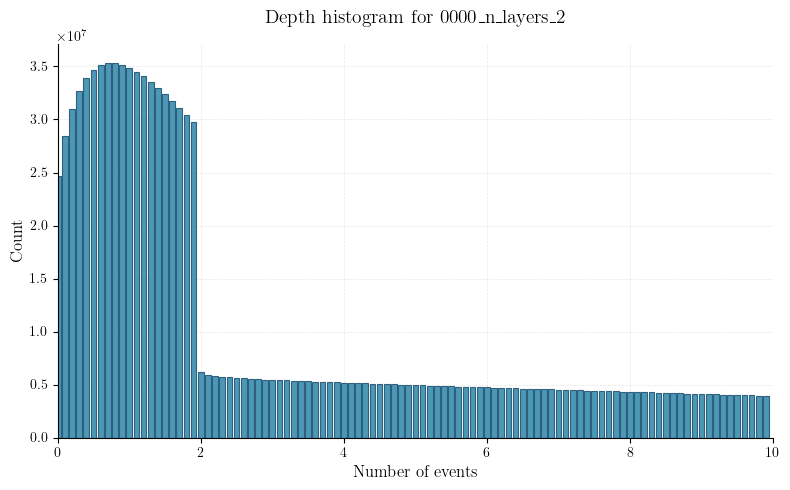

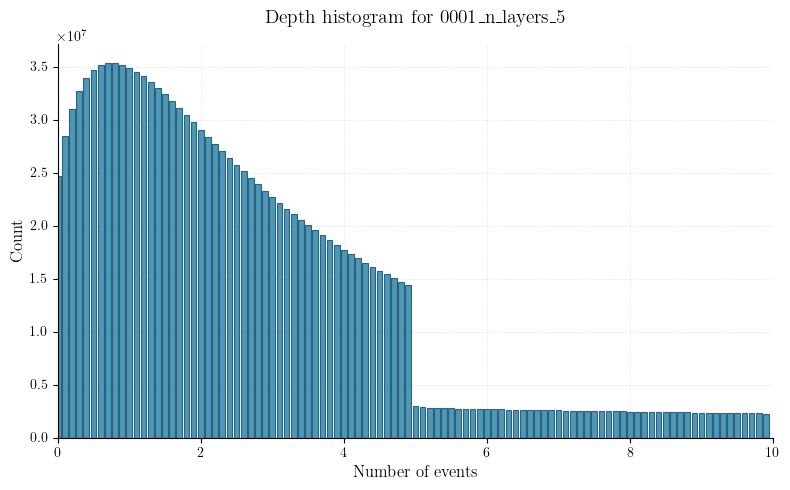

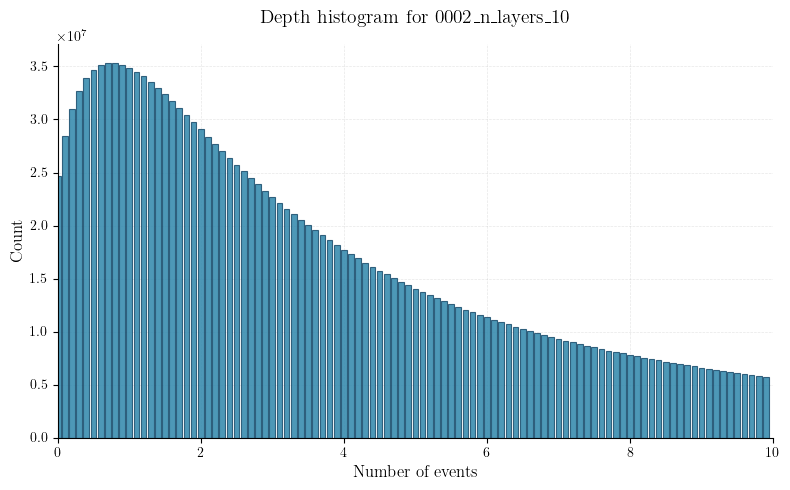

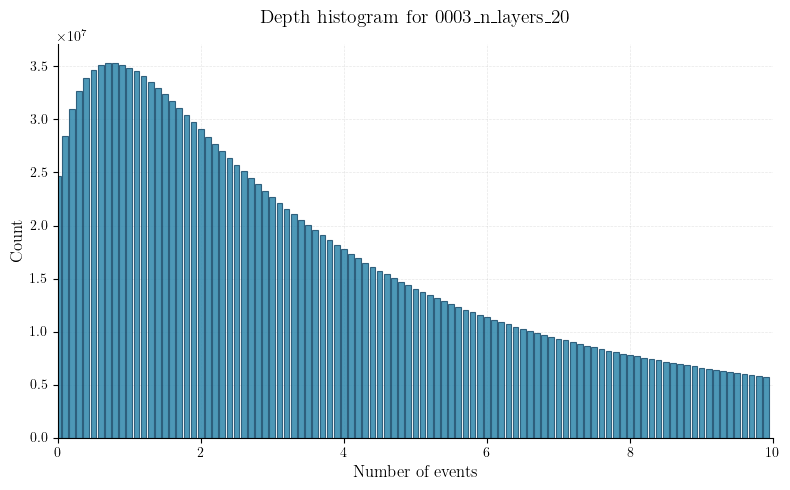

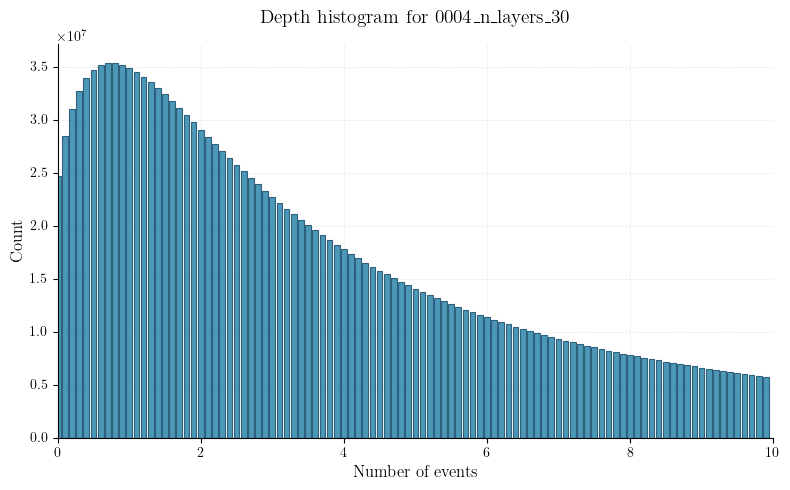

In [33]:
for dic_name in dic_names:
    events_hist = dic_name['sts']['depth']['list']
    dt_events = dic_name['sts']['depth']['dt']
    max_val = dic_name['sts']['depth']['N']
    plot_histogram(events_hist, dt_events, title=f"Depth histogram for {dic_name['name']}", xlabel="Number of events", ylabel="Count", max_x=max_val)

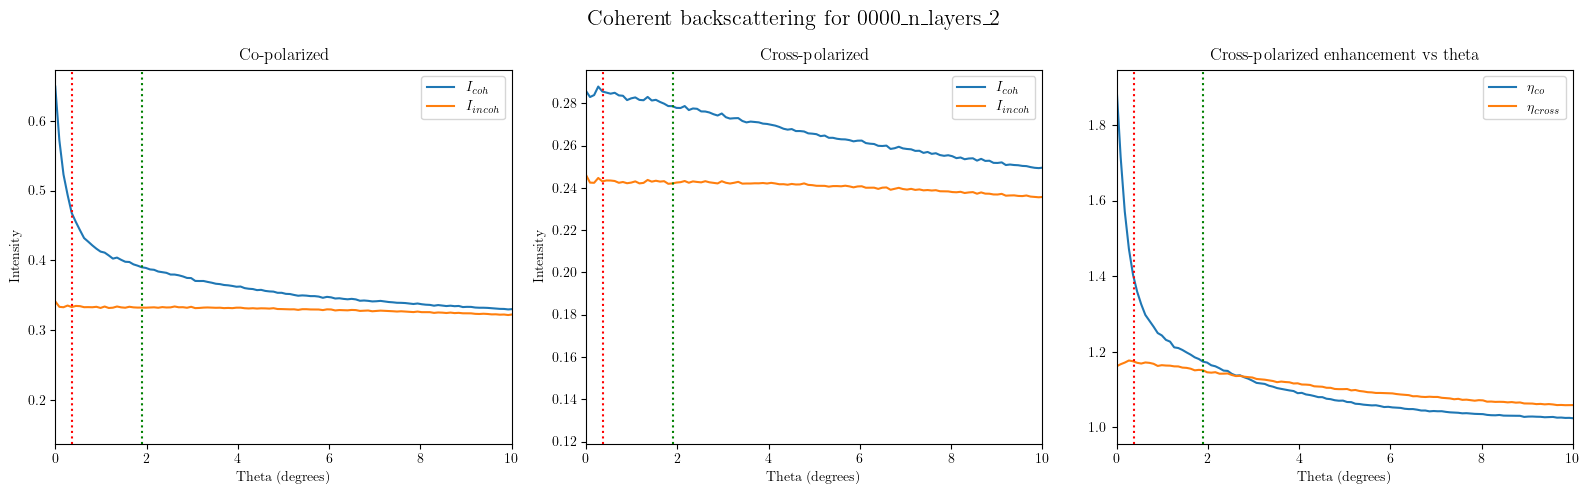

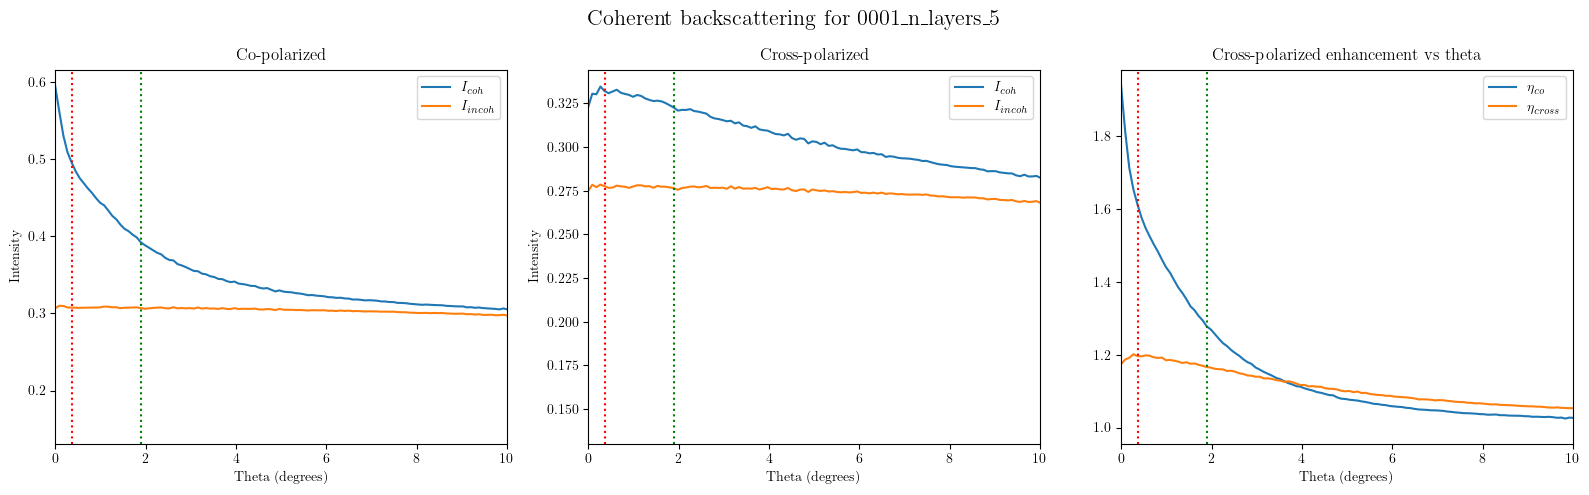

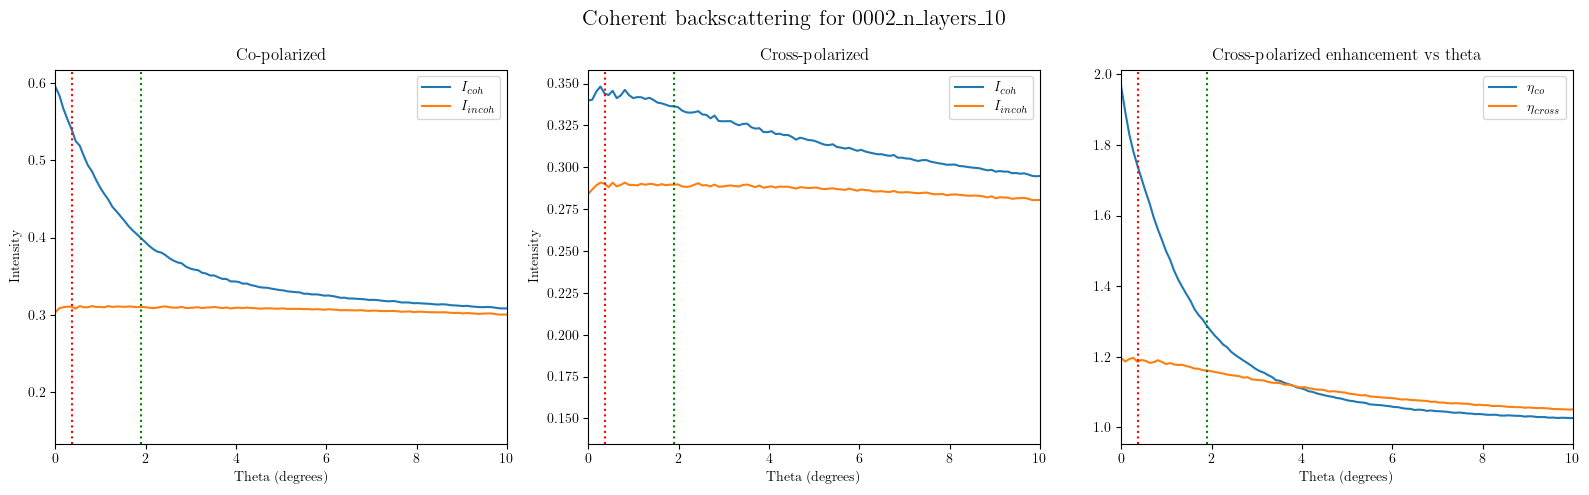

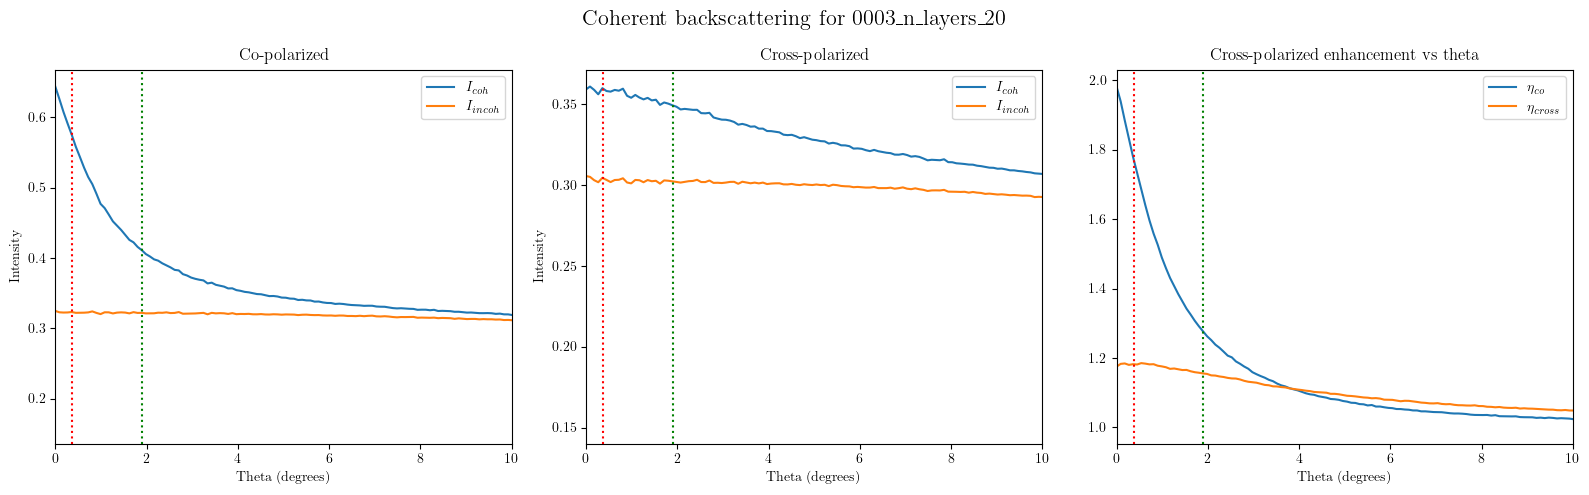

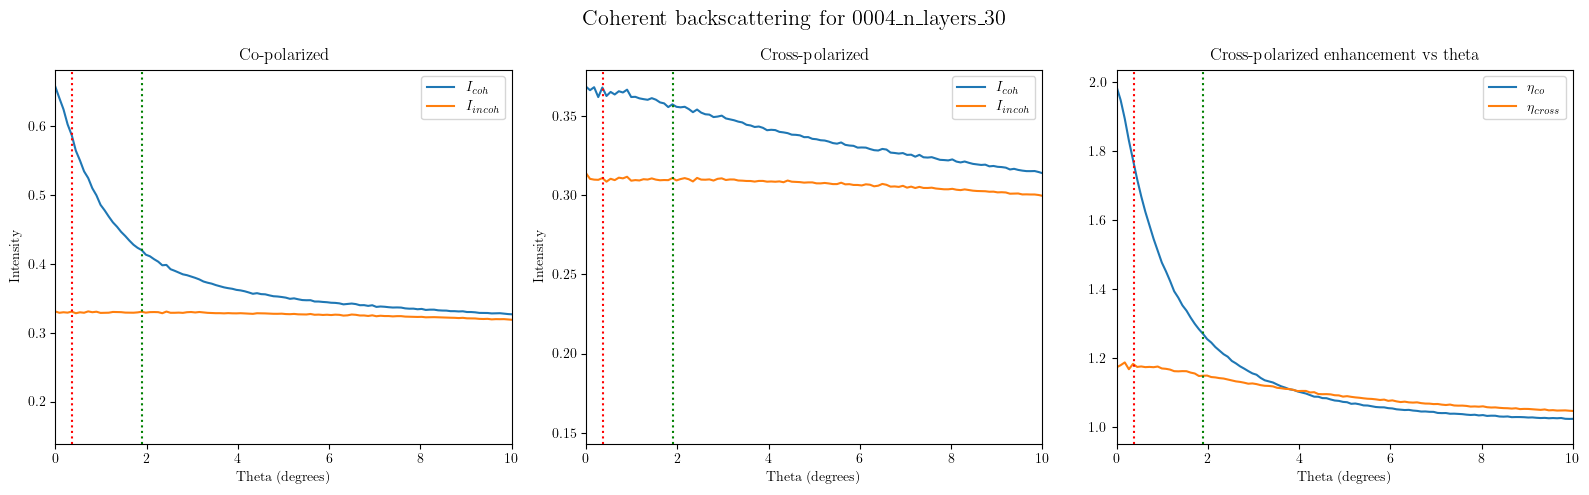

In [34]:

for dic_name in dic_names:
    Ico_coh_radial = dic_name['ff']['co-polarized']['coh']
    Icross_coh_radial = dic_name['ff']['cross-polarized']['coh']
    Ico_incoh_radial = dic_name['ff']['co-polarized']['icoh']
    Icross_incoh_radial = dic_name['ff']['cross-polarized']['icoh']
    etaco = dic_name['ff']['co-polarized']['enhancement']
    etacross = dic_name['ff']['cross-polarized']['enhancement']

    plot_data(theta_deg_list, Ico_coh_radial, Icross_coh_radial, Ico_incoh_radial, Icross_incoh_radial, etaco, etacross, title=f'Coherent backscattering for {dic_name["name"]}', max_x=10)

In [35]:
def plot_comparation(all_y_data, x_list, labels, title, xlabel, ylabel, max_x=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for y_data, label in zip(all_y_data, labels):
        ax.plot(x_list, y_data, label=label)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    if max_x is not None:
        ax.set_xlim(0, max_x)
    
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    
    ax.legend()
    plt.tight_layout()
    plt.show()

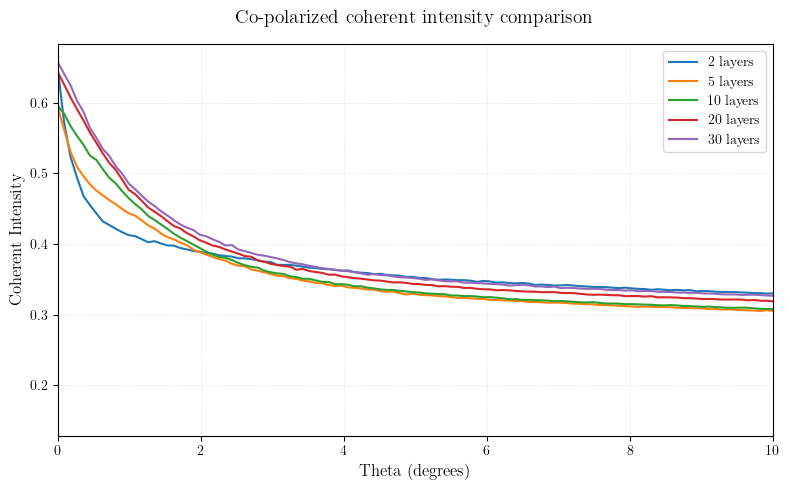

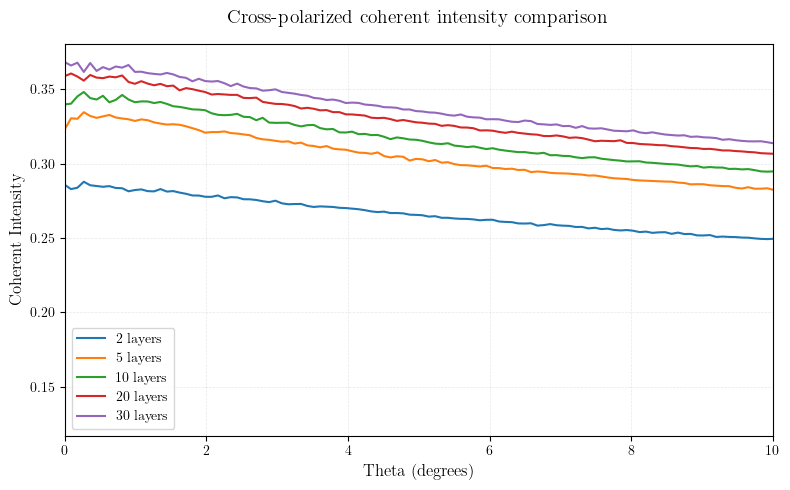

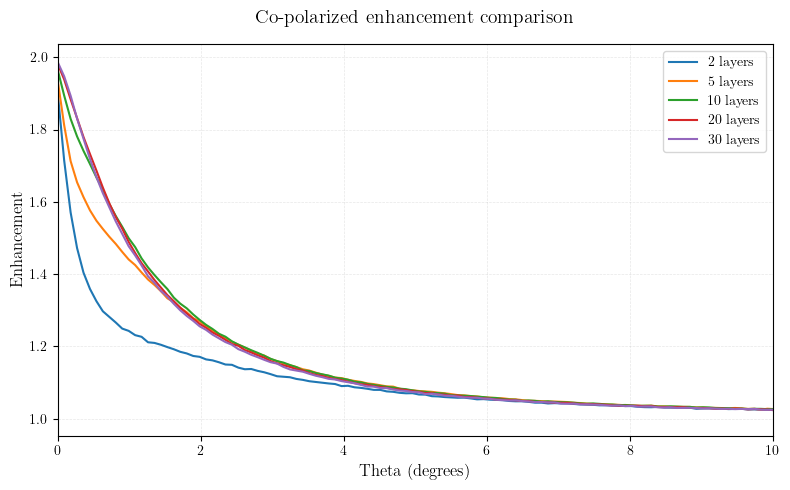

In [37]:
plot_comparation(
    all_y_data=[dic_name['ff']['co-polarized']['coh'] for dic_name in dic_names],
    x_list=theta_deg_list,
    labels=[f"{dic_name['n']} layers" for dic_name in dic_names],
    title="Co-polarized coherent intensity comparison",
    xlabel="Theta (degrees)",
    ylabel="Coherent Intensity",
    max_x=10
)

plot_comparation(
    all_y_data=[dic_name['ff']['cross-polarized']['coh'] for dic_name in dic_names],
    x_list=theta_deg_list,
    labels=[f"{dic_name['n']} layers" for dic_name in dic_names],
    title="Cross-polarized coherent intensity comparison",
    xlabel="Theta (degrees)",
    ylabel="Coherent Intensity",
    max_x=10
)

plot_comparation(
    all_y_data=[dic_name['ff']['co-polarized']['enhancement'] for dic_name in dic_names],
    x_list=theta_deg_list,
    labels=[f"{dic_name['n']} layers" for dic_name in dic_names],
    title="Co-polarized enhancement comparison",
    xlabel="Theta (degrees)",
    ylabel="Enhancement",
    max_x=10
)